In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Dropout,
    Flatten,
    SimpleRNN,
    LSTM,
    GRU,
    Bidirectional
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import os

In [2]:
X_train_pad = np.load(
    "processed_data/X_train.npy"
)

X_val_pad = np.load(
    "processed_data/X_val.npy"
)

X_test_pad = np.load(
    "processed_data/X_test.npy"
)

y_train = np.load(
    "processed_data/y_train.npy"
)

y_val = np.load(
    "processed_data/y_val.npy"
)

y_test = np.load(
    "processed_data/y_test.npy"
)

In [3]:
print("X_train:", X_train_pad.shape)
print("X_val:", X_val_pad.shape)
print("X_test:", X_test_pad.shape)

X_train: (34998, 200)
X_val: (7502, 200)
X_test: (7500, 200)


In [4]:
VOCAB_SIZE = 20000

MAX_LENGTH = 200

EMBEDDING_DIM = 128

EPOCHS = 5

BATCH_SIZE = 64

In [5]:
os.makedirs("saved_models", exist_ok=True)

In [6]:
def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):

    probabilities = model.predict(X_test)

    probabilities = probabilities.flatten()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    print(f"\n{model_name} Results")

    print("Accuracy:", accuracy)

    print("Precision:", precision)

    print("Recall:", recall)

    print("F1 Score:", f1)

    print("ROC-AUC:", roc_auc)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [7]:
ann_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [8]:
ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
ann_history = ann_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7918 - loss: 0.4242 - val_accuracy: 0.8708 - val_loss: 0.3036
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9661 - loss: 0.1001 - val_accuracy: 0.8463 - val_loss: 0.4520
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9931 - loss: 0.0218 - val_accuracy: 0.8464 - val_loss: 0.6624
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9967 - loss: 0.0099 - val_accuracy: 0.8447 - val_loss: 0.7960
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9964 - loss: 0.0109 - val_accuracy: 0.8435 - val_loss: 0.8039


In [10]:
ann_model.save(
    "saved_models/ann_model.keras"
)

In [11]:
ann_results = evaluate_model(
    ann_model,
    X_test_pad,
    y_test,
    "ANN"
)

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

ANN Results
Accuracy: 0.8494666666666667
Precision: 0.8364569961489089
Recall: 0.8688
F1 Score: 0.852321778940484
ROC-AUC: 0.9238680533333334


In [12]:
rnn_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    SimpleRNN(
        64,
        dropout=0.2
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [13]:
rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.4997 - loss: 0.6943 - val_accuracy: 0.5049 - val_loss: 0.6931
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.5180 - loss: 0.6922 - val_accuracy: 0.5157 - val_loss: 0.6931
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.5351 - loss: 0.6866 - val_accuracy: 0.5083 - val_loss: 0.6981
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.5705 - loss: 0.6595 - val_accuracy: 0.5181 - val_loss: 0.7046
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.5931 - loss: 0.6308 - val_accuracy: 0.5268 - val_loss: 0.7142


In [15]:
rnn_model.save(
    "saved_models/rnn_model.keras"
)

In [16]:
rnn_results = evaluate_model(
    rnn_model,
    X_test_pad,
    y_test,
    "Simple RNN"
)

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Simple RNN Results
Accuracy: 0.5128
Precision: 0.5080971659919028
Recall: 0.8032
F1 Score: 0.6224426534407935
ROC-AUC: 0.5327634488888888


In [17]:
lstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    LSTM(
        64,
        dropout=0.2
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [18]:
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [19]:
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 57s 102ms/step - accuracy: 0.5163 - loss: 0.6920 - val_accuracy: 0.5240 - val_loss: 0.6914
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 56s 102ms/step - accuracy: 0.5073 - loss: 0.6902 - val_accuracy: 0.5132 - val_loss: 0.6879
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 56s 102ms/step - accuracy: 0.5133 - loss: 0.6898 - val_accuracy: 0.5778 - val_loss: 0.6606
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 56s 102ms/step - accuracy: 0.5401 - loss: 0.6853 - val_accuracy: 0.5396 - val_loss: 0.6899
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 56s 102ms/step - accuracy: 0.6740 - loss: 0.5716 - val_accuracy: 0.8494 - val_loss: 0.3631


In [20]:
lstm_model.save(
    "saved_models/lstm_model.keras"
)

In [25]:
lstm_results = evaluate_model(
    lstm_model,
    X_test_pad,
    y_test,
    "lstm"
)

235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step

lstm Results
Accuracy: 0.8596
Precision: 0.8485396743344533
Recall: 0.8754666666666666
F1 Score: 0.8617928862055387
ROC-AUC: 0.9255992177777776


In [26]:
gru_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    GRU(
        64,
        dropout=0.2
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [27]:
gru_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [28]:
gru_history = gru_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 54s 96ms/step - accuracy: 0.5223 - loss: 0.6881 - val_accuracy: 0.5352 - val_loss: 0.6847
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.7716 - loss: 0.4479 - val_accuracy: 0.8794 - val_loss: 0.2932
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 53s 97ms/step - accuracy: 0.9194 - loss: 0.2181 - val_accuracy: 0.8834 - val_loss: 0.2913
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.9540 - loss: 0.1323 - val_accuracy: 0.8778 - val_loss: 0.3394
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.9757 - loss: 0.0777 - val_accuracy: 0.8656 - val_loss: 0.4183


In [29]:
gru_model.save(
    "saved_models/gru_model.keras"
)

In [30]:
gru_results = evaluate_model(
    gru_model,
    X_test_pad,
    y_test,
    "GRU"
)

235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

GRU Results
Accuracy: 0.8722666666666666
Precision: 0.8873473917869035
Recall: 0.8528
F1 Score: 0.869730758770737
ROC-AUC: 0.9435921066666666


In [31]:
bilstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    Bidirectional(
        LSTM(
            64,
            dropout=0.2
        )
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [32]:
bilstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [33]:
bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 82s 147ms/step - accuracy: 0.7890 - loss: 0.4397 - val_accuracy: 0.8639 - val_loss: 0.3193
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 85s 156ms/step - accuracy: 0.9057 - loss: 0.2528 - val_accuracy: 0.8635 - val_loss: 0.3690
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 86s 157ms/step - accuracy: 0.9371 - loss: 0.1794 - val_accuracy: 0.8644 - val_loss: 0.3595
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 86s 158ms/step - accuracy: 0.9563 - loss: 0.1293 - val_accuracy: 0.8619 - val_loss: 0.4519
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 86s 157ms/step - accuracy: 0.9669 - loss: 0.0962 - val_accuracy: 0.8659 - val_loss: 0.5113


In [34]:
bilstm_model.save(
    "saved_models/bilstm_model.keras"
)

In [35]:
bilstm_results = evaluate_model(
    bilstm_model,
    X_test_pad,
    y_test,
    "Bidirectional LSTM"
)

235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step

Bidirectional LSTM Results
Accuracy: 0.8637333333333334
Precision: 0.8755506607929515
Recall: 0.848
F1 Score: 0.8615551341099973
ROC-AUC: 0.9281076977777777


In [36]:
results_list = [

    ann_results,

    rnn_results,

    lstm_results,

    gru_results,

    bilstm_results
]

results_df = pd.DataFrame(
    results_list
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANN,0.849467,0.836457,0.868800,0.852322,0.923868
1,Simple RNN,0.512800,0.508097,0.803200,0.622443,0.532763
2,lstm,0.859600,0.848540,0.875467,0.861793,0.925599
3,GRU,0.872267,0.887347,0.852800,0.869731,0.943592
4,Bidirectional LSTM,0.863733,0.875551,0.848000,0.861555,0.928108


In [37]:
results_df = results_df.round(4)

print(results_df)

                Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0                 ANN    0.8495     0.8365  0.8688    0.8523   0.9239
1          Simple RNN    0.5128     0.5081  0.8032    0.6224   0.5328
2                lstm    0.8596     0.8485  0.8755    0.8618   0.9256
3                 GRU    0.8723     0.8873  0.8528    0.8697   0.9436
4  Bidirectional LSTM    0.8637     0.8756  0.8480    0.8616   0.9281


In [38]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,GRU,0.8723,0.8873,0.8528,0.8697,0.9436
4,Bidirectional LSTM,0.8637,0.8756,0.8480,0.8616,0.9281
2,lstm,0.8596,0.8485,0.8755,0.8618,0.9256
0,ANN,0.8495,0.8365,0.8688,0.8523,0.9239
1,Simple RNN,0.5128,0.5081,0.8032,0.6224,0.5328


In [39]:
results_df.to_csv(
    "saved_models/model_comparison.csv",
    index=False
)

In [40]:
def plot_accuracy(
    history,
    model_name
):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(
        f"{model_name} Accuracy"
    )

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")

    plt.legend()

    plt.show()

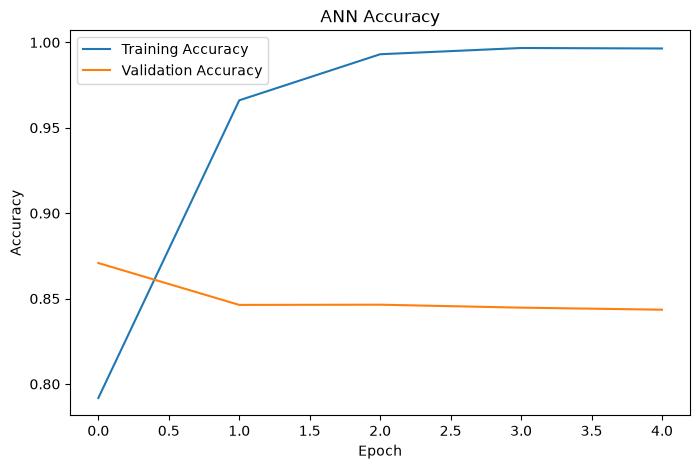

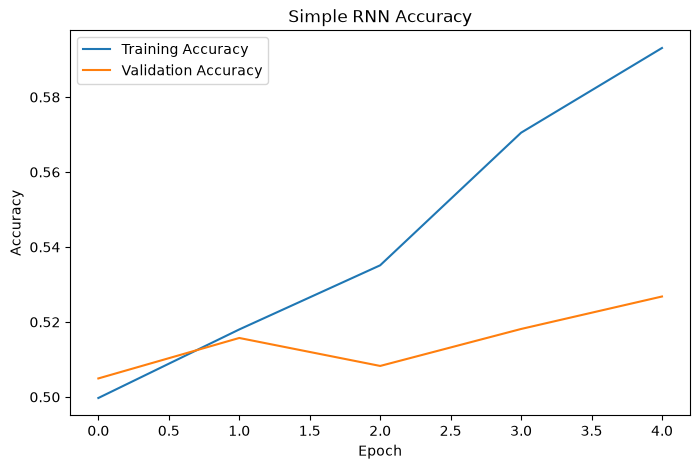

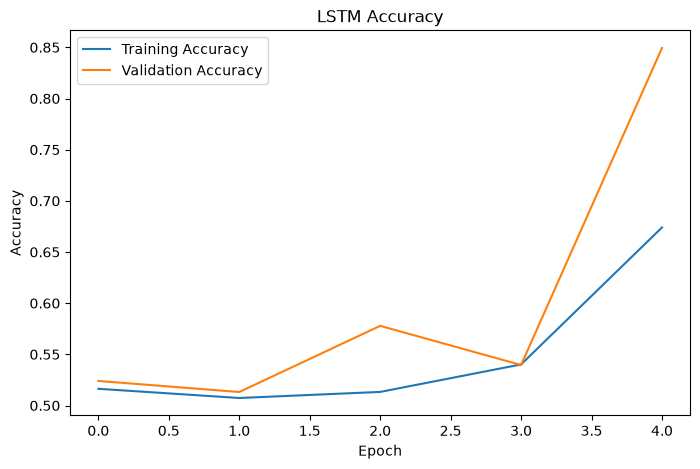

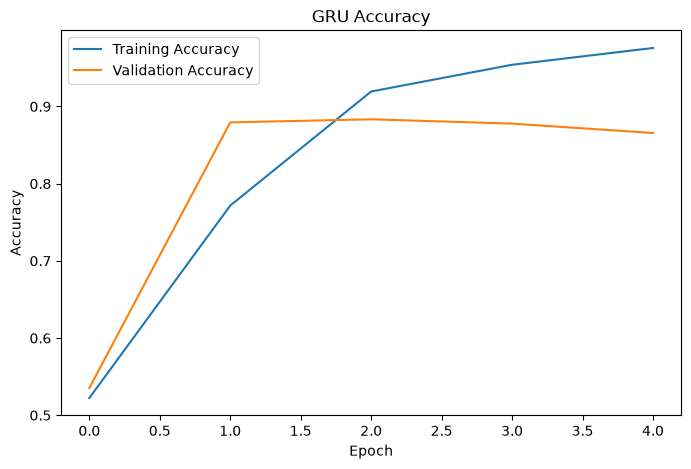

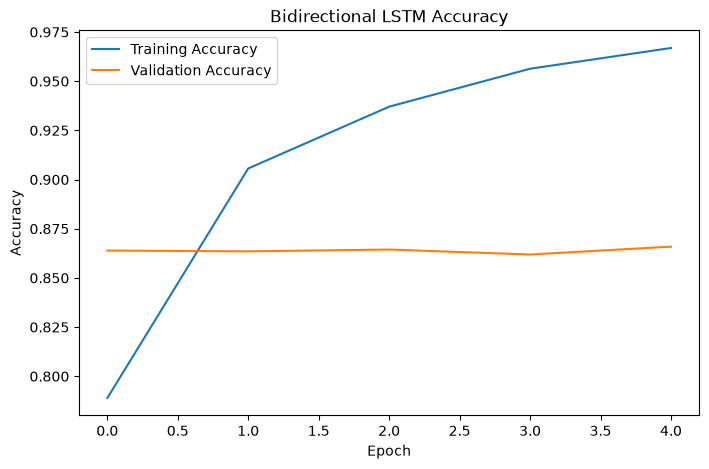

In [41]:
plot_accuracy(
    ann_history,
    "ANN"
)

plot_accuracy(
    rnn_history,
    "Simple RNN"
)

plot_accuracy(
    lstm_history,
    "LSTM"
)

plot_accuracy(
    gru_history,
    "GRU"
)

plot_accuracy(
    bilstm_history,
    "Bidirectional LSTM"
)

In [42]:
def plot_loss(
    history,
    model_name
):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        f"{model_name} Loss"
    )

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.legend()

    plt.show()

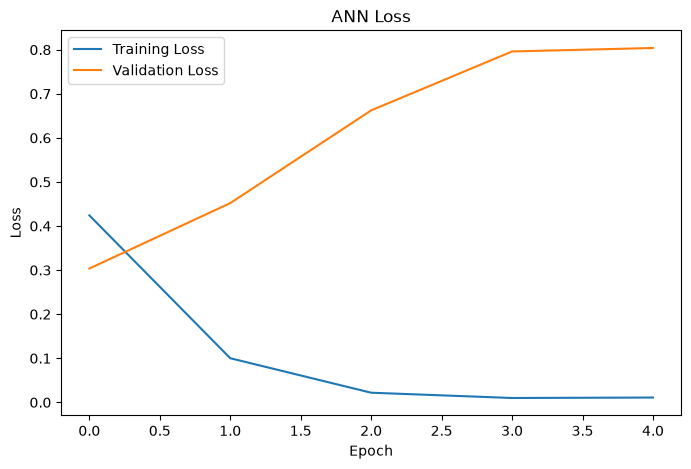

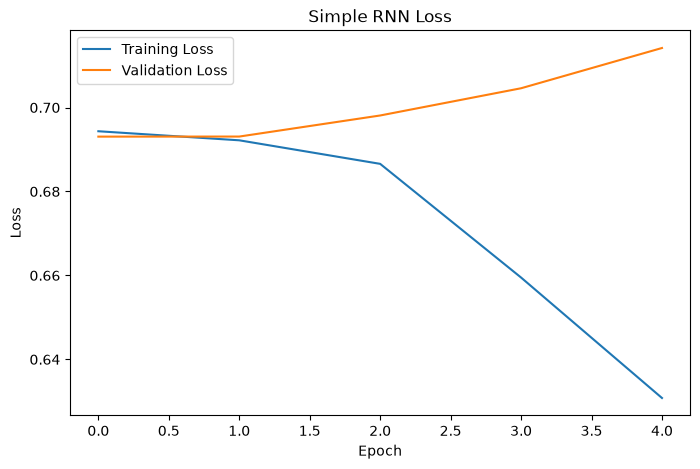

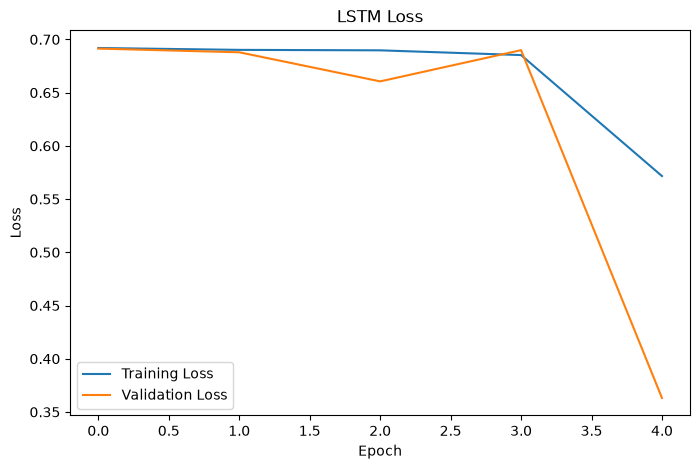

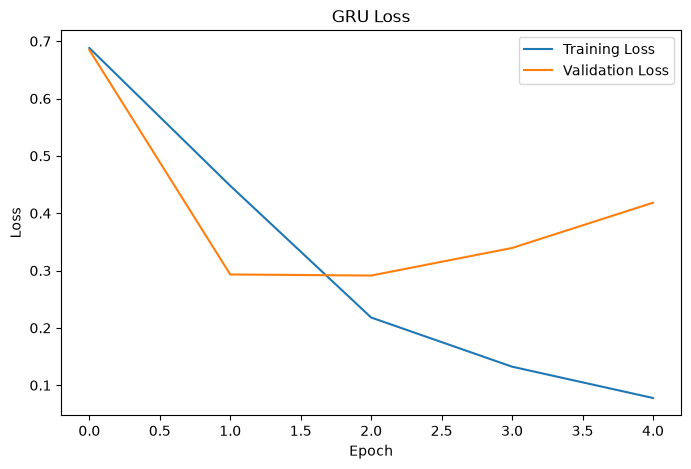

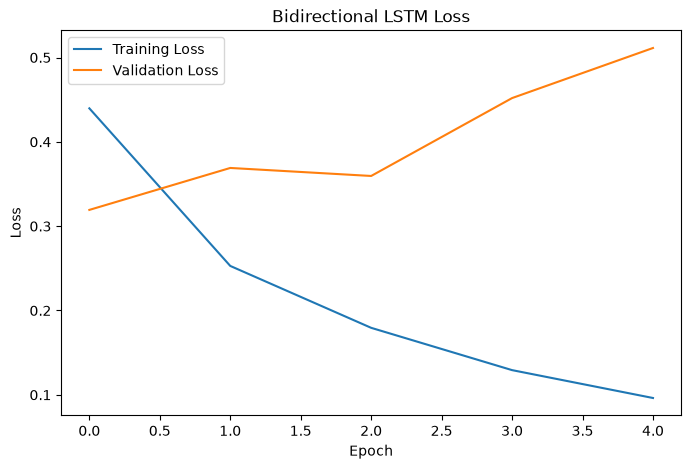

In [43]:
plot_loss(
    ann_history,
    "ANN"
)

plot_loss(
    rnn_history,
    "Simple RNN"
)

plot_loss(
    lstm_history,
    "LSTM"
)

plot_loss(
    gru_history,
    "GRU"
)

plot_loss(
    bilstm_history,
    "Bidirectional LSTM"
)

In [44]:
sample_predictions = gru_model.predict(
    X_test_pad[:10]
)

sample_predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[5.6564255e-04],
       [6.3368441e-03],
       [2.3065712e-03],
       [5.6755656e-01],
       [9.9836689e-01],
       [9.9771094e-01],
       [9.9706501e-01],
       [4.4962138e-02],
       [9.9956691e-01],
       [5.7294974e-03]], dtype=float32)

In [45]:
predicted_labels = (
    sample_predictions.flatten() >= 0.5
).astype(int)

comparison_predictions = pd.DataFrame({

    "Actual": y_test[:10],

    "Predicted": predicted_labels,

    "Probability": sample_predictions.flatten()
})

comparison_predictions

,Actual,Predicted,Probability
0,0,0,0.000566
1,0,0,0.006337
2,0,0,0.002307
3,0,1,0.567557
4,1,1,0.998367
5,1,1,0.997711
6,1,1,0.997065
7,0,0,0.044962
8,1,1,0.999567
9,0,0,0.005729


In [46]:
def plot_confusion_matrix(
    model,
    X_test,
    y_test,
    model_name
):

    probabilities = model.predict(X_test)

    predictions = (
        probabilities.flatten() >= 0.5
    ).astype(int)

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Negative",
            "Positive"
        ],
        yticklabels=[
            "Negative",
            "Positive"
        ]
    )

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


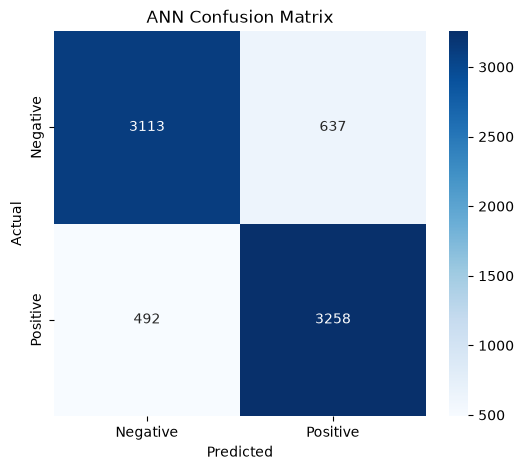

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


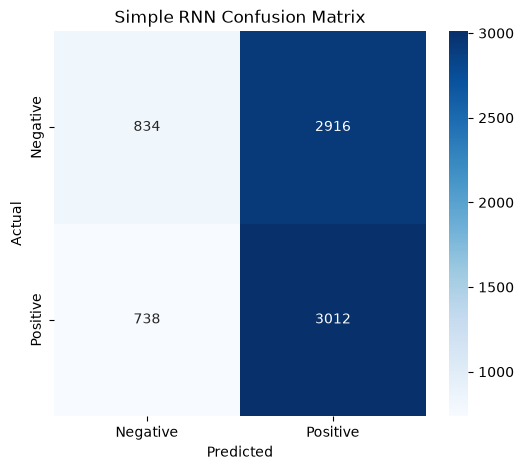

235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step


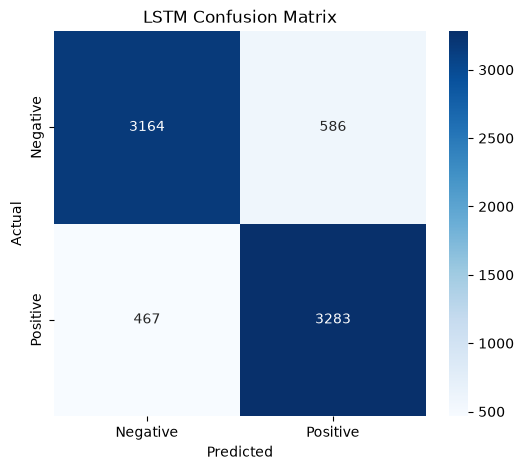

235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


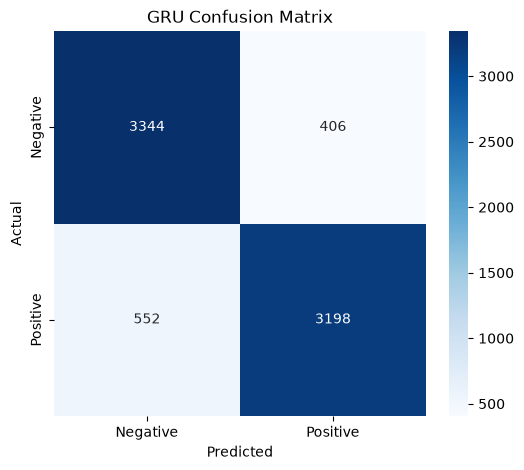

235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step


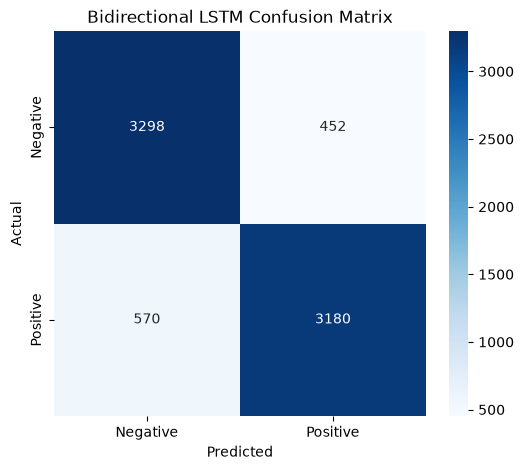

In [47]:
plot_confusion_matrix(
    ann_model,
    X_test_pad,
    y_test,
    "ANN"
)

plot_confusion_matrix(
    rnn_model,
    X_test_pad,
    y_test,
    "Simple RNN"
)

plot_confusion_matrix(
    lstm_model,
    X_test_pad,
    y_test,
    "LSTM"
)

plot_confusion_matrix(
    gru_model,
    X_test_pad,
    y_test,
    "GRU"
)

plot_confusion_matrix(
    bilstm_model,
    X_test_pad,
    y_test,
    "Bidirectional LSTM"
)